# **Extreme Classification by Optimizing Compositional Entropic Risk (SCENT)**


## Prerequisites

In [1]:
# !gdown --folder 'https://drive.google.com/drive/folders/10cY2Azqz9Gnci-r4fXcGIpH_e5YaKXH_?usp=sharing' -O ./features

In [2]:
# !git clone https://github.com/xywei00/LibAUC.git -b xiyuan/1.5.0_dev

In [3]:
# !pip install ./LibAUC

In [4]:
import os
import logging
import pathlib
import json
import sys
import random
import math

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

from libauc.losses import EntLossClassification
from libauc.optimizers import SCENT

## Helper Functions

In [5]:
class LinearClassifier(nn.Module):
    def __init__(self, feature_dim: int, num_classes: int):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_classes = num_classes
        self.fc = nn.Linear(feature_dim, num_classes, bias=False)
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)

    def forward(
        self,
        x: torch.Tensor,
        labels: torch.Tensor,
        classes: torch.Tensor | str | None = None,
        return_classes: bool = False,
    ):
        w_pos = self.fc.weight[labels]  # (B, D)

        mask = None
        sampled_classes = None
        if isinstance(classes, str):
            assert classes == "all"
            sampled_classes = torch.arange(self.num_classes, device=labels.device)
            w_sampled = self.fc.weight
        elif isinstance(classes, torch.Tensor):
            sampled_classes = classes.to(labels.device)
            w_sampled = self.fc.weight[sampled_classes]
        elif classes is None:
            sampled_classes = torch.unique(labels)
            w_sampled = self.fc.weight[sampled_classes]
            mask = labels.unsqueeze(1) == sampled_classes.unsqueeze(0)
        else:
            raise ValueError(f"Unknown classes type: {type(classes)}")

        logits = x @ w_sampled.T - torch.sum(x * w_pos, dim=1, keepdim=True)

        if mask is not None:
            logits = logits.masked_fill(mask.to(logits.device), float("-inf"))

        if return_classes:
            return logits, sampled_classes
        return logits

In [6]:
class FeaturesDataset(Dataset):
    """Dataset for precomputed features.

    Expects features_path (N, D) and labels_path (N,) where labels are ints 0..C-1.
    """

    def __init__(self, features_path: str, labels_path: str):
        self.features = torch.load(features_path)
        self.labels = torch.load(labels_path)
        assert self.features.shape[0] == self.labels.shape[0], "features/labels length mismatch"

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]
        return x, y, idx

In [7]:
def setup_logging(out_log_file=None):
    logging.root.handlers = []
    logging.root.setLevel(level=logging.INFO)

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s", datefmt="%Y-%m-%d,%H:%M:%S"
    )

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logging.root.addHandler(stream_handler)

    if out_log_file is not None:
        file_handler = logging.FileHandler(out_log_file)
        file_handler.setFormatter(formatter)
        logging.root.addHandler(file_handler)


def build_dataloaders(root_data_dir, batch_size, num_workers=0):
    dataloader_list = []
    for split, shuffle in zip(["train", "val", "test"], [True, False, False]):
        data_dir = os.path.join(root_data_dir, split)
        if not os.path.exists(data_dir):
            if split in ["train", "val"]:
                raise FileNotFoundError(f"Data directory {data_dir} does not exist.")
            dataloader_list.append(None)
            continue

        features = os.path.join(data_dir, "features.pt")
        labels = os.path.join(data_dir, "labels.pt")
        ds = FeaturesDataset(features, labels)
        dataloader = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
        )
        dataloader_list.append(dataloader)

    train_loader, val_loader, test_loader = dataloader_list
    return train_loader, val_loader, test_loader


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    logging.info(f"Set random seed to {seed}")


def compute_log_priors(train_loader, num_classes):
    counts = torch.zeros(num_classes, dtype=torch.float32)
    for _, labels, _ in train_loader:
        counts += torch.bincount(labels, minlength=num_classes).float()
    priors = counts / counts.sum()
    priors = priors.clamp_min(1e-12)
    return priors.log()


def apply_la_to_sampled_logits(logits, sampled_classes, labels, log_priors, tau):
    if tau <= 0:
        return logits
    neg_shift = log_priors[sampled_classes].unsqueeze(0)
    pos_shift = log_priors[labels].unsqueeze(1)
    return logits + tau * (neg_shift - pos_shift)


def evaluate(model, loader, device, log_priors=None, eval_tau=0.0):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, batch in enumerate(loader):
            feats, labels, _ = batch
            feats = feats.to(device)
            labels = labels.to(device, dtype=torch.long)

            logits = model.fc(feats)

            if log_priors is not None and eval_tau > 0:
                logits = logits + eval_tau * log_priors.to(device).unsqueeze(0)

            loss = F.cross_entropy(logits, labels)
            total_loss += loss.item() * feats.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += feats.size(0)

            if i % 100 == 0:
                logging.info(f"  Batch {i} / {len(loader)}: loss={loss.item():.6f}")

    return total_loss / total, correct / total


def train_one_epoch(model, loader, optimizer, criterion, device, log_priors=None, train_tau=0.0):
    model.train()
    total_loss = 0.0
    total = 0

    for i, batch in enumerate(loader):
        feats, labels, indices = batch
        feats = feats.to(device)
        labels = labels.to(device, dtype=torch.long)

        logits, sampled_classes = model(feats, labels, return_classes=True)
        logits = apply_la_to_sampled_logits(logits, sampled_classes, labels, log_priors, train_tau)

        loss_dict = criterion(logits, indices)
        loss = loss_dict["loss"]

        with torch.no_grad():
            model.eval()
            base_logits = model.fc(feats)
            cross_entropy_loss = F.cross_entropy(base_logits, labels)
            loss_dict["cross_entropy_loss"] = cross_entropy_loss
            model.train()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += cross_entropy_loss.item() * feats.size(0)
        total += feats.size(0)

        if i % 100 == 0:
            log_str = f"  Batch {i} / {len(loader)}:"
            for key, value in loss_dict.items():
                log_str += f" {key}={value.item():.6f}"
            logging.info(log_str)

    return total_loss / total


def make_scheduler(optimizer, epochs, warmup_epochs=0):
    def lr_lambda(epoch_idx):
        epoch_num = epoch_idx + 1
        if warmup_epochs > 0 and epoch_num <= warmup_epochs:
            return epoch_num / warmup_epochs

        if epochs == warmup_epochs:
            return 1.0

        progress = (epoch_num - warmup_epochs) / max(1, epochs - warmup_epochs)
        progress = min(max(progress, 0.0), 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


def forward_with_weight_snapshot(weight_snapshot_cpu, feats, labels, sampled_classes):
    """
    Rebuild sampled logits using a frozen previous weight snapshot.
    Only rows in sampled_classes are used.
    """
    rows = sampled_classes.detach().cpu()
    local_weight = weight_snapshot_cpu[rows].to(feats.device)  # (K, D)

    mask = labels.unsqueeze(1) == sampled_classes.unsqueeze(0)  # (B, K)
    pos_idx = mask.float().argmax(dim=1)  # (B,)

    w_pos = local_weight[pos_idx]  # (B, D)
    logits = feats @ local_weight.t() - torch.sum(feats * w_pos, dim=1, keepdim=True)
    logits = logits.masked_fill(mask, float("-inf"))
    return logits


def init_msvr_state(data_size):
    return {
        "u": torch.ones(data_size, dtype=torch.float32),
        "prev_weight": None,
    }


def batch_inner_exp_from_logits(logits):
    """
    Approximate E[exp(s_i)] from sampled logits in the current batch.
    Ignores masked positive entries (-inf).
    """
    finite_mask = torch.isfinite(logits)
    exp_logits = torch.where(finite_mask, torch.exp(logits), torch.zeros_like(logits))
    counts = finite_mask.sum(dim=1).clamp_min(1)
    return exp_logits.sum(dim=1) / counts


def train_one_epoch_msvr_dual(
    model,
    loader,
    optimizer,
    criterion,
    device,
    msvr_state,
    msvr_gamma=0.10,
    msvr_eps=1e-8,
    log_priors=None,
    train_tau=0.0,
):
    model.train()
    total_loss = 0.0
    total = 0

    data_n = len(loader.dataset)

    for i, batch in enumerate(loader):
        feats, labels, indices = batch
        feats = feats.to(device)
        labels = labels.to(device, dtype=torch.long)
        idx_cpu = indices.long().cpu()

        # current logits under current model
        logits, sampled_classes = model(feats, labels, return_classes=True)
        logits = apply_la_to_sampled_logits(logits, sampled_classes, labels, log_priors, train_tau)

        with torch.no_grad():
            g_curr = batch_inner_exp_from_logits(logits.detach())

            if msvr_state["prev_weight"] is None:
                g_prev = g_curr
            else:
                prev_logits = forward_with_weight_snapshot(
                    msvr_state["prev_weight"], feats, labels, sampled_classes
                )
                prev_logits = apply_la_to_sampled_logits(
                    prev_logits, sampled_classes, labels, log_priors, train_tau
                )
                g_prev = batch_inner_exp_from_logits(prev_logits)

            u_prev = msvr_state["u"][idx_cpu].to(device)
            B = feats.size(0)

            gamma = msvr_gamma
            gamma_corr = ((data_n - B) / max(B, 1)) * (1.0 - gamma)

            u_raw = (1.0 - gamma) * u_prev + gamma * g_curr + gamma_corr * (g_curr - g_prev)
            u_new = torch.clamp(u_raw, min=msvr_eps)

            msvr_state["u"][idx_cpu] = u_new.detach().cpu()

            if hasattr(criterion, "nu"):
                criterion.nu[idx_cpu] = torch.log(u_new).detach().cpu().unsqueeze(1)

        optimizer.zero_grad()
        loss_dict = criterion(logits, indices)
        loss = loss_dict["loss"]
        loss.backward()

        weight_before_step = model.fc.weight.detach().cpu().clone()
        optimizer.step()
        msvr_state["prev_weight"] = weight_before_step

        with torch.no_grad():
            model.eval()
            base_logits = model.fc(feats)
            cross_entropy_loss = F.cross_entropy(base_logits, labels)
            loss_dict["cross_entropy_loss"] = cross_entropy_loss
            model.train()

        total_loss += cross_entropy_loss.item() * feats.size(0)
        total += feats.size(0)

        if i % 100 == 0:
            log_str = f"  Batch {i} / {len(loader)}:"
            for key, value in loss_dict.items():
                log_str += f" {key}={value.item():.6f}"
            logging.info(log_str)

    return total_loss / total, msvr_state

In [8]:
data_dir = "./features/treeoflife10m_subset"
root_out_dir = "./outputs_exp3_msvr/"

seed = 2026
device = "cuda"
feature_dim = 512
num_classes = 163002
data_size = 762654
save_frequency = 1

epochs = 20
batch_size = 128

setup_logging()

In [14]:
EXPERIMENTS = [
    dict(
        name="exp3_cfg01_scent_ref",
        algorithm="scent",
        lr=0.002,
        alpha=0.0,
        alpha_multiplier=0.03,
        momentum=0.9,
        weight_decay=0.0,
        train_tau=0.0,
        eval_tau=0.0,
        warmup_epochs=0,
        use_msvr=False,
        msvr_gamma=0.10,
        msvr_eps=1e-8,
    ),
    dict(
        name="exp3_cfg02_scent_warmup_ref",
        algorithm="scent",
        lr=0.002,
        alpha=0.0,
        alpha_multiplier=0.03,
        momentum=0.9,
        weight_decay=0.0,
        train_tau=0.0,
        eval_tau=0.0,
        warmup_epochs=2,
        use_msvr=False,
        msvr_gamma=0.10,
        msvr_eps=1e-8,
    ),
    dict(
        name="exp3_cfg03_scent_msvr_dual",
        algorithm="scent",
        lr=0.002,
        alpha=0.0,
        alpha_multiplier=0.0,  # freeze internal SCENT dual update; dual is now external
        momentum=0.9,
        weight_decay=0.0,
        train_tau=0.0,
        eval_tau=0.0,
        warmup_epochs=0,
        use_msvr=True,
        msvr_gamma=0.10,
        msvr_eps=1e-8,
    ),
    dict(
        name="exp3_cfg04_scent_warmup_msvr_dual",
        algorithm="scent",
        lr=0.002,
        alpha=0.0,
        alpha_multiplier=0.0,
        momentum=0.9,
        weight_decay=0.0,
        train_tau=0.0,
        eval_tau=0.0,
        warmup_epochs=2,
        use_msvr=True,
        msvr_gamma=0.10,
        msvr_eps=1e-8,
    ),
]

## Training

In [ ]:
def build_experiment(cfg):
    name = cfg["name"]
    out_dir = pathlib.Path(root_out_dir) / name
    os.makedirs(out_dir / "checkpoints", exist_ok=True)
    out_log_file = out_dir / "out.log"

    setup_logging(out_log_file)
    set_seed(seed)

    train_loader, val_loader, test_loader = build_dataloaders(data_dir, batch_size, num_workers=0)
    model = LinearClassifier(feature_dim, num_classes).to(device)

    optimizer = SCENT(
        model.parameters(),
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        weight_decay=cfg["weight_decay"],
    )

    lr_scheduler = make_scheduler(
        optimizer,
        epochs=epochs,
        warmup_epochs=cfg["warmup_epochs"],
    )

    if cfg["algorithm"] == "scent":
        criterion = EntLossClassification(
            data_size=data_size,
            alpha=cfg["alpha"],
            is_scent=True,
            alpha_multiplier=cfg["alpha_multiplier"],
        )
    elif cfg["algorithm"] == "sox":
        criterion = EntLossClassification(
            data_size=data_size,
            gamma=cfg["gamma"],
            is_scent=False,
        )
    else:
        raise ValueError(cfg["algorithm"])

    log_priors = compute_log_priors(train_loader, num_classes).to(device)

    return {
        "name": name,
        "out_dir": out_dir,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "model": model,
        "optimizer": optimizer,
        "lr_scheduler": lr_scheduler,
        "criterion": criterion,
        "log_priors": log_priors,
    }


def run_experiment(cfg):
    exp = build_experiment(cfg)

    name = exp["name"]
    out_dir = exp["out_dir"]
    train_loader = exp["train_loader"]
    val_loader = exp["val_loader"]
    test_loader = exp["test_loader"]
    model = exp["model"]
    optimizer = exp["optimizer"]
    lr_scheduler = exp["lr_scheduler"]
    criterion = exp["criterion"]
    log_priors = exp["log_priors"]

    best_val_acc = 0.0
    best_test_acc = 0.0
    best_test_loss = float("inf")
    all_rows = []

    msvr_state = init_msvr_state(data_size) if cfg.get("use_msvr", False) else None

    for epoch in range(1, epochs + 1):
        logging.info(
            f"{name} | Epoch {epoch}/{epochs}, learning_rate={lr_scheduler.get_last_lr()[0]:.6f}"
        )

        if hasattr(criterion, "adjust_gamma"):
            criterion.adjust_gamma(epoch, epochs)

        if cfg.get("use_msvr", False):
            train_ce, msvr_state = train_one_epoch_msvr_dual(
                model,
                train_loader,
                optimizer,
                criterion,
                device,
                msvr_state=msvr_state,
                msvr_gamma=cfg["msvr_gamma"],
                msvr_eps=cfg["msvr_eps"],
                log_priors=log_priors,
                train_tau=cfg["train_tau"],
            )
        else:
            train_ce = train_one_epoch(
                model,
                train_loader,
                optimizer,
                criterion,
                device,
                log_priors=log_priors,
                train_tau=cfg["train_tau"],
            )

        lr_scheduler.step()

        logging.info("Evaluating on validation set")
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            device,
            log_priors=log_priors,
            eval_tau=cfg["eval_tau"],
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            if test_loader is not None:
                logging.info("Evaluating on test set")
                best_test_loss, best_test_acc = evaluate(
                    model,
                    test_loader,
                    device,
                    log_priors=log_priors,
                    eval_tau=cfg["eval_tau"],
                )

        row = {
            "epoch": epoch,
            "cross_entropy_loss": train_ce,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "best_val_acc": best_val_acc,
            "best_test_acc": best_test_acc,
            "best_test_loss": best_test_loss,
        }
        all_rows.append(row)

        logging.info(
            f"{name} | epoch={epoch} train_ce={train_ce:.6f} "
            f"val_loss={val_loss:.6f} val_acc={val_acc:.6f} "
            f"best_val_acc={best_val_acc:.6f} "
            f"best_test_acc={best_test_acc:.6f}"
        )

        with open(out_dir / f"eval_{name}.jsonl", "a") as f:
            f.write(json.dumps(row) + "\n")

        if epoch % save_frequency == 0 or epoch == epochs:
            save_dict = {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
                "config": cfg,
            }
            if hasattr(criterion, "nu"):
                save_dict["criterion_nu"] = criterion.nu.cpu()
            if cfg.get("use_msvr", False):
                save_dict["msvr_u"] = msvr_state["u"]
            torch.save(save_dict, out_dir / "checkpoints" / f"epoch_{epoch}.pt")

    return all_rows

In [ ]:
# run_experiment(EXPERIMENTS[0])  # exp3_cfg01_scent_ref
run_experiment(EXPERIMENTS[2])  # exp3_cfg03_scent_msvr_dual

2026-04-20,20:19:20 | INFO | Set random seed to 2026
2026-04-20,20:19:26 | INFO | exp3_cfg03_scent_msvr_dual | Epoch 1/20, learning_rate=0.001988
2026-04-20,20:19:26 | INFO |   Batch 0 / 5959: loss=1.000640 cross_entropy_loss=12.002987
2026-04-20,20:19:31 | INFO |   Batch 100 / 5959: loss=1.117738 cross_entropy_loss=11.969075
2026-04-20,20:19:35 | INFO |   Batch 200 / 5959: loss=1.066063 cross_entropy_loss=11.968937
2026-04-20,20:19:39 | INFO |   Batch 300 / 5959: loss=1.101712 cross_entropy_loss=11.924221
2026-04-20,20:19:44 | INFO |   Batch 400 / 5959: loss=1.062277 cross_entropy_loss=11.924140
2026-04-20,20:19:48 | INFO |   Batch 500 / 5959: loss=1.053077 cross_entropy_loss=11.907442
2026-04-20,20:19:52 | INFO |   Batch 600 / 5959: loss=1.090410 cross_entropy_loss=11.827197
2026-04-20,20:19:57 | INFO |   Batch 700 / 5959: loss=1.086328 cross_entropy_loss=11.800119
2026-04-20,20:20:01 | INFO |   Batch 800 / 5959: loss=1.079296 cross_entropy_loss=11.817324
2026-04-20,20:20:06 | INFO |

[{'epoch': 1,
  'cross_entropy_loss': 11.659129814772664,
  'val_loss': 11.551799689807694,
  'val_acc': 0.1354858335693531,
  'best_val_acc': 0.1354858335693531,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 2,
  'cross_entropy_loss': 11.327733357257213,
  'val_loss': 11.16871135206397,
  'val_acc': 0.14123422601252478,
  'best_val_acc': 0.14123422601252478,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 3,
  'cross_entropy_loss': 10.962191727748209,
  'val_loss': 10.861767413384067,
  'val_acc': 0.15379047738930673,
  'best_val_acc': 0.15379047738930673,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 4,
  'cross_entropy_loss': 10.643627021271117,
  'val_loss': 10.592292263114919,
  'val_acc': 0.17206365190756417,
  'best_val_acc': 0.17206365190756417,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 5,
  'cross_entropy_loss': 10.357105732635613,
  'val_loss': 10.36470153463782,
  'val_acc': 0.1930536761389265,
  'best_val_acc': 0

In [15]:
run_experiment(EXPERIMENTS[1])
run_experiment(EXPERIMENTS[3])

2026-04-20,21:54:08 | INFO | Set random seed to 2026
2026-04-20,21:54:13 | INFO | exp3_cfg02_scent_warmup_ref | Epoch 1/20, learning_rate=0.001000
2026-04-20,21:54:13 | INFO |   Batch 0 / 5959: loss=1.000000 cross_entropy_loss=12.003008
2026-04-20,21:54:14 | INFO |   Batch 100 / 5959: loss=1.000000 cross_entropy_loss=11.993044
2026-04-20,21:54:15 | INFO |   Batch 200 / 5959: loss=1.000000 cross_entropy_loss=11.993399
2026-04-20,21:54:15 | INFO |   Batch 300 / 5959: loss=1.000000 cross_entropy_loss=11.982556
2026-04-20,21:54:16 | INFO |   Batch 400 / 5959: loss=1.000000 cross_entropy_loss=11.982896
2026-04-20,21:54:17 | INFO |   Batch 500 / 5959: loss=1.000000 cross_entropy_loss=11.977548
2026-04-20,21:54:18 | INFO |   Batch 600 / 5959: loss=1.000000 cross_entropy_loss=11.955412
2026-04-20,21:54:19 | INFO |   Batch 700 / 5959: loss=1.000000 cross_entropy_loss=11.950295
2026-04-20,21:54:20 | INFO |   Batch 800 / 5959: loss=1.000000 cross_entropy_loss=11.953843
2026-04-20,21:54:21 | INFO 

[{'epoch': 1,
  'cross_entropy_loss': 11.753083501106726,
  'val_loss': 11.662984520577373,
  'val_acc': 0.1339857968551678,
  'best_val_acc': 0.1339857968551678,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 2,
  'cross_entropy_loss': 11.360675622551783,
  'val_loss': 11.135197070307907,
  'val_acc': 0.13706978842139492,
  'best_val_acc': 0.13706978842139492,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 3,
  'cross_entropy_loss': 10.878853116887793,
  'val_loss': 10.721924930816243,
  'val_acc': 0.1472133933348019,
  'best_val_acc': 0.1472133933348019,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 4,
  'cross_entropy_loss': 10.471359819091516,
  'val_loss': 10.397132478544265,
  'val_acc': 0.16274873860549036,
  'best_val_acc': 0.16274873860549036,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 5,
  'cross_entropy_loss': 10.165206510553041,
  'val_loss': 10.18471280175281,
  'val_acc': 0.1833611312164983,
  'best_val_acc': 0.

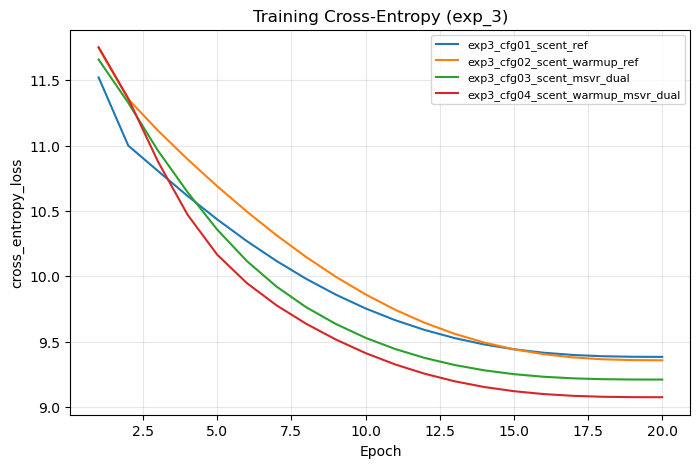

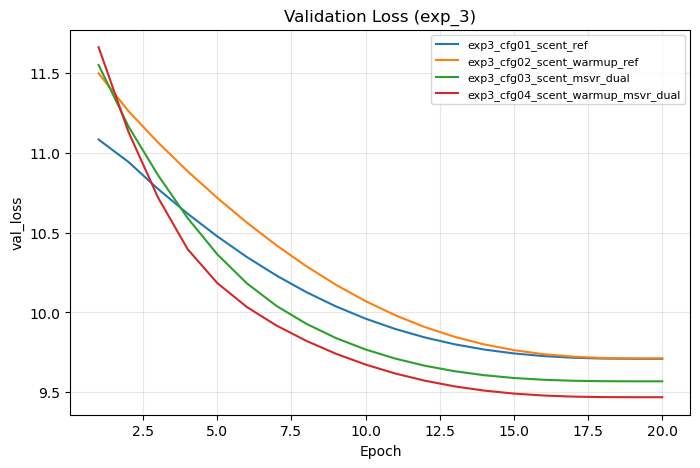

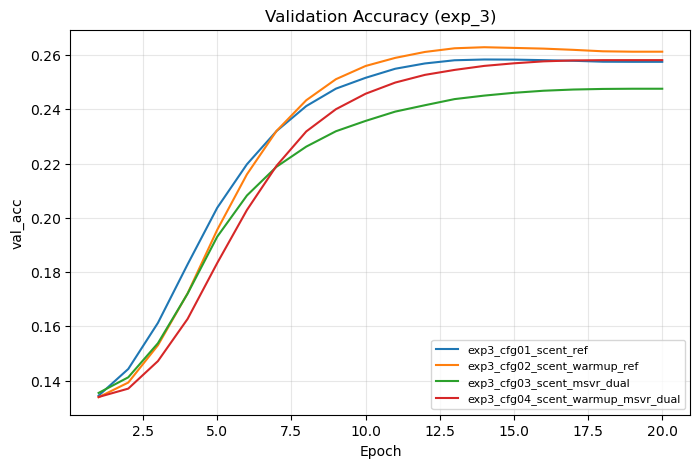

In [16]:
import glob
import matplotlib.pyplot as plt

def load_jsonl(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


def load_run(name):
    path = pathlib.Path(root_out_dir) / name / f"eval_{name}.jsonl"
    return load_jsonl(path)


def plot_metric(names, metric, title):
    plt.figure(figsize=(8, 5))
    for name in names:
        rows = load_run(name)
        xs = [r["epoch"] for r in rows]
        ys = [r[metric] for r in rows]
        plt.plot(xs, ys, label=name)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()

names = [cfg["name"] for cfg in EXPERIMENTS]

plot_metric(names, "cross_entropy_loss", "Training Cross-Entropy (exp_3)")
plot_metric(names, "val_loss", "Validation Loss (exp_3)")
plot_metric(names, "val_acc", "Validation Accuracy (exp_3)")